# Vesper Capital — Signal Filter Analysis

Runs both the **24-hour** and **1-hour** walk-forward models on the same data and joins them on timestamp to determine whether the 1-hour model adds value as a confirmation filter for 24-hour entries.

**Four signal regimes:**
- **both**: 24h AND 1h both fire — highest conviction
- **24h_only**: only 24h fires — current strategy
- **1h_only**: only 1h fires — not traded (1h edge too small)
- **flat**: neither fires — cash

**Key question:** does requiring both models to agree produce materially better 24-hour returns than the 24h model alone?

**Design note:** wallet features are shifted 1 hour back (D21) for both models — conservative for 24h, required for 1h.

## 1. Configuration

In [1]:
from claude_refactor_core_utils import *
from dateutil.relativedelta import relativedelta
from datetime import date, timedelta
import pandas as pd
import numpy as np
import os
import calendar
import xgboost as xgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats as scipy_stats
import warnings
warnings.filterwarnings('ignore')

# ── Window ─────────────────────────────────────────────────────
FULL_START       = date(2023, 1, 1)
FULL_END         = date(2024, 12, 31)
MIN_DELTA_ETH    = 0.005
ROLLING_WINDOWS  = [6, 24, 72, 168]

# ── Walk-forward ───────────────────────────────────────────────
TRAIN_MONTHS     = 4
VAL_MONTHS       = 2
MIN_VAL_ACTIVE   = 10

# ── Model ──────────────────────────────────────────────────────
MODEL_PARAMS = dict(
    n_estimators=200, max_depth=3, learning_rate=0.02,
    subsample=0.6, colsample_bytree=0.3, min_child_weight=50,
    reg_alpha=1.0, reg_lambda=5.0, random_state=42,
    n_jobs=-1, verbosity=0
)

# ── Threshold filters ──────────────────────────────────────────
THRESHOLD_SEARCH_24H = np.arange(0.0, 2.0,  0.05)
THRESHOLD_SEARCH_1H  = np.arange(0.0, 0.5,  0.01)
MIN_THRESHOLD_24H    = 0.50   # D22: skip always-long months
MIN_THRESHOLD_1H     = 0.05

# ── Files ──────────────────────────────────────────────────────
HOURLY_BALANCE_CSV = '/home/colin/projects/blockchain_alpha/data/balance_store_hourly_top200.csv'

print("Signal Filter Analysis — 1h vs 24h model comparison")
print(f"Window: {FULL_START} to {FULL_END}")


Signal Filter Analysis — 1h vs 24h model comparison
Window: 2023-01-01 to 2024-12-31


## 2. Load data

In [2]:
print("Loading hourly balance store...")
raw = pd.read_csv(HOURLY_BALANCE_CSV)
raw['date']        = pd.to_datetime(raw['date'], format='mixed').dt.floor('h')
raw['address']     = raw['address'].str.lower().str.strip()
raw['balance_wei'] = pd.to_numeric(raw['balance_wei'], errors='coerce').fillna(0).astype('int64')

hourly = (
    raw.sort_values(['address','date','block_number'])
    .groupby(['address','date'], as_index=False).tail(1)
    .reset_index(drop=True)
)
hourly['balance_eth'] = hourly['balance_wei'] / 1e18
hourly = hourly.sort_values(['address','date'])
hourly['delta_eth'] = hourly.groupby('address')['balance_eth'].diff()
hourly['action_raw'] = hourly['delta_eth'].apply(
    lambda d: 1 if d > MIN_DELTA_ETH else (-1 if d < -MIN_DELTA_ETH else 0)
)
wallet_list = sorted(hourly['address'].unique().tolist())

print("Loading hourly prices...")
df_price = load_eth_usd_cryptocompare(
    start=str(FULL_START), end=str(FULL_END), interval='1h'
)
df_price['date'] = pd.to_datetime(df_price['date']).dt.floor('h')
df_price = df_price.sort_values('date').reset_index(drop=True)

# Both forward return targets
df_price['fwd_1h']  = (df_price['close'].shift(-1)  - df_price['close']) / df_price['close'] * 100
df_price['fwd_24h'] = (df_price['close'].shift(-24) - df_price['close']) / df_price['close'] * 100

# Price context features
df_price['ret_1h']      = df_price['close'].pct_change(1)  * 100
df_price['ret_4h']      = df_price['close'].pct_change(4)  * 100
df_price['ret_24h']     = df_price['close'].pct_change(24) * 100
df_price['ret_72h']     = df_price['close'].pct_change(72) * 100
df_price['vol_24h']     = df_price['ret_1h'].rolling(24).std()
df_price['vol_72h']     = df_price['ret_1h'].rolling(72).std()
df_price['hour_of_day'] = df_price['date'].dt.hour
df_price['day_of_week'] = df_price['date'].dt.dayofweek

print(f"Wallets: {len(wallet_list)}, Hours: {len(df_price):,}")


Loading hourly balance store...
Loading hourly prices...
Wallets: 201, Hours: 17,521


## 3. Build feature matrix

In [3]:
print("Building feature matrix...")

action_wide = hourly.pivot_table(
    index='date', columns='address', values='action_raw', aggfunc='first'
).fillna(0)
delta_wide = hourly.pivot_table(
    index='date', columns='address', values='delta_eth', aggfunc='first'
).fillna(0)

wallet_features = pd.DataFrame(index=action_wide.index)
for addr in wallet_list:
    if addr not in action_wide.columns:
        continue
    short = addr[:10]
    act   = action_wide[addr]
    dlt   = delta_wide[addr]
    wallet_features[f'{short}_action']     = act
    wallet_features[f'{short}_wtd_action'] = dlt * act.abs()
    for w in ROLLING_WINDOWS:
        wallet_features[f'{short}_buy_pressure_{w}h'] = (
            (act > 0).astype(float).rolling(w, min_periods=1).mean()
        )
    wallet_features[f'{short}_max_buy_24h'] = dlt.clip(lower=0).rolling(24, min_periods=1).max()

buy_matrix  = (action_wide > 0).astype(float)
sell_matrix = (action_wide < 0).astype(float)
wallet_features['pool_buy_fraction']   = buy_matrix.mean(axis=1)
wallet_features['pool_sell_fraction']  = sell_matrix.mean(axis=1)
wallet_features['pool_net_fraction']   = (
    wallet_features['pool_buy_fraction'] - wallet_features['pool_sell_fraction']
)
buy_pressure  = delta_wide.clip(lower=0).sum(axis=1)
sell_pressure = delta_wide.clip(upper=0).abs().sum(axis=1)
total_vol     = buy_pressure + sell_pressure + 1e-9
wallet_features['pool_net_pressure_eth'] = (buy_pressure - sell_pressure) / total_vol
for w in [6, 24, 72]:
    wallet_features[f'pool_buy_fraction_{w}h'] = (
        wallet_features['pool_buy_fraction'].rolling(w, min_periods=1).mean()
    )
    wallet_features[f'pool_net_pressure_{w}h'] = (
        wallet_features['pool_net_pressure_eth'].rolling(w, min_periods=1).mean()
    )
n_active = (action_wide != 0).sum(axis=1).clip(lower=1)
n_agree  = buy_matrix.sum(axis=1).combine(sell_matrix.sum(axis=1), max)
wallet_features['pool_conviction'] = n_agree / n_active

# ── D21: shift wallet features 1h back ────────────────────────
# Required for 1h target. Conservative but harmless for 24h target.
print("  Applying 1-hour causal shift (D21)...")
wallet_cols = list(wallet_features.columns)
wallet_features[wallet_cols] = wallet_features[wallet_cols].shift(1)

feature_df = wallet_features.reset_index().rename(columns={'date':'timestamp'})

price_cols = ['date','close','fwd_1h','fwd_24h',
              'ret_1h','ret_4h','ret_24h','ret_72h',
              'vol_24h','vol_72h','hour_of_day','day_of_week']

full_df = feature_df.merge(
    df_price[price_cols].rename(columns={'date':'timestamp'}),
    on='timestamp', how='inner'
).dropna().reset_index(drop=True)

FEATURE_COLS = [c for c in full_df.columns
                if c not in ['timestamp','close','fwd_1h','fwd_24h']]

print(f"Feature matrix: {full_df.shape}, Features: {len(FEATURE_COLS)}")


Building feature matrix...
  Applying 1-hour causal shift (D21)...
Feature matrix: (17425, 1430), Features: 1426


## 4. Walk-forward fold schedule

In [4]:
folds = []
cursor = FULL_START

while True:
    train_start = cursor
    train_end_month = train_start.month + TRAIN_MONTHS + VAL_MONTHS - 1
    train_end = date(
        train_start.year + (train_end_month - 1) // 12,
        (train_end_month - 1) % 12 + 1,
        calendar.monthrange(
            train_start.year + (train_end_month - 1) // 12,
            (train_end_month - 1) % 12 + 1
        )[1]
    )
    test_start = train_end + timedelta(days=1)
    test_end   = date(
        test_start.year + (test_start.month - 1) // 12,
        test_start.month,
        calendar.monthrange(test_start.year, test_start.month)[1]
    )
    if test_end > FULL_END:
        break
    folds.append({
        'train_start': train_start, 'train_end': train_end,
        'test_start':  test_start,  'test_end':  test_end,
    })
    next_month = cursor.month + 1
    next_year  = cursor.year + (next_month - 1) // 12
    next_month = (next_month - 1) % 12 + 1
    cursor = date(next_year, next_month, 1)

print(f"Walk-forward folds: {len(folds)}")


Walk-forward folds: 18


## 5. Run both walk-forward models

Both models use identical architecture and fold structure. The only difference is the target column and threshold search range.

In [5]:
def run_walkforward(full_df, folds, feature_cols, target_col,
                    model_params, threshold_search, min_val_active,
                    label="model"):
    results = []
    for fold_idx, fold in enumerate(folds):
        val_start        = fold['train_end'] - relativedelta(months=2) + relativedelta(days=1)
        train_end_actual = val_start - relativedelta(days=1)

        train_mask = ((full_df['timestamp'].dt.date >= fold['train_start']) &
                      (full_df['timestamp'].dt.date <= train_end_actual))
        val_mask   = ((full_df['timestamp'].dt.date >= val_start) &
                      (full_df['timestamp'].dt.date <= fold['train_end']))
        test_mask  = ((full_df['timestamp'].dt.date >= fold['test_start']) &
                      (full_df['timestamp'].dt.date <= fold['test_end']))

        train_fold = full_df[train_mask].copy()
        val_fold   = full_df[val_mask].copy()
        test_fold  = full_df[test_mask].copy()

        if len(train_fold) < 200 or len(val_fold) < 100 or len(test_fold) < 50:
            continue

        X_train = train_fold[feature_cols].values
        y_train = train_fold[target_col].values
        X_val   = val_fold[feature_cols].values
        y_val   = val_fold[target_col].values
        X_test  = test_fold[feature_cols].values

        model_fold = xgb.XGBRegressor(**model_params)
        model_fold.fit(X_train, y_train)

        y_pred_val  = model_fold.predict(X_val)
        y_pred_test = model_fold.predict(X_test)

        best_threshold = 0.0
        best_val_edge  = -999
        base_val_mean  = y_val.mean()

        for threshold in threshold_search:
            pos   = (y_pred_val > threshold).astype(float)
            n_act = int(pos.sum())
            if n_act < min_val_active:
                continue
            active = pd.Series(pos * y_val)[pos > 0]
            edge   = active.mean() - base_val_mean
            if edge > best_val_edge:
                best_val_edge  = edge
                best_threshold = threshold

        results.append({
            'fold':          fold_idx + 1,
            'test_month':    fold['test_start'].strftime('%Y-%m'),
            'test_start':    fold['test_start'],
            'test_end':      fold['test_end'],
            'threshold':     best_threshold,
            'timestamps':    test_fold['timestamp'].values,
            'actual_returns_target': test_fold[target_col].values,
            'actual_returns_24h':    test_fold['fwd_24h'].values,
            'actual_returns_1h':     test_fold['fwd_1h'].values,
            'close':         test_fold['close'].values,
            'y_pred':        y_pred_test,
            'positions':     (y_pred_test > best_threshold).astype(float),
        })

        active_t = test_fold[target_col].values[(y_pred_test > best_threshold)]
        base_t   = test_fold[target_col].values.mean()
        edge_t   = active_t.mean() - base_t if len(active_t) > 0 else 0
        print(f"  Fold {fold_idx+1:2d} [{label}]: "
              f"test {fold['test_start']}  "
              f"thr={best_threshold:.3f}  "
              f"n={len(active_t):4d}  "
              f"edge={edge_t:+.5f}%")

    return results

print("Running 24h walk-forward...")
long_results_24h = run_walkforward(
    full_df, folds, FEATURE_COLS, 'fwd_24h',
    MODEL_PARAMS, THRESHOLD_SEARCH_24H, MIN_VAL_ACTIVE, label="24h"
)
print(f"  {len(long_results_24h)} folds complete")
print()
print("Running 1h walk-forward...")
long_results_1h = run_walkforward(
    full_df, folds, FEATURE_COLS, 'fwd_1h',
    MODEL_PARAMS, THRESHOLD_SEARCH_1H, MIN_VAL_ACTIVE, label="1h"
)
print(f"  {len(long_results_1h)} folds complete")


Running 24h walk-forward...
  Fold  1 [24h]: test 2023-07-01  thr=0.150  n=  14  edge=+2.11011%
  Fold  2 [24h]: test 2023-08-01  thr=0.000  n=   0  edge=+0.00000%
  Fold  3 [24h]: test 2023-09-01  thr=0.400  n=  93  edge=+0.72532%
  Fold  4 [24h]: test 2023-10-01  thr=0.600  n=  84  edge=+0.10697%
  Fold  5 [24h]: test 2023-11-01  thr=0.650  n=  31  edge=+1.68255%
  Fold  6 [24h]: test 2023-12-01  thr=1.100  n=  20  edge=+1.98573%
  Fold  7 [24h]: test 2024-01-01  thr=1.050  n= 107  edge=+0.28018%
  Fold  8 [24h]: test 2024-02-01  thr=1.950  n=   0  edge=+0.00000%
  Fold  9 [24h]: test 2024-03-01  thr=1.350  n=  38  edge=+3.61581%
  Fold 10 [24h]: test 2024-04-01  thr=1.650  n=   0  edge=+0.00000%
  Fold 11 [24h]: test 2024-05-01  thr=1.850  n=  57  edge=-0.70100%
  Fold 12 [24h]: test 2024-06-01  thr=1.800  n=   0  edge=+0.00000%
  Fold 13 [24h]: test 2024-07-01  thr=0.600  n=  89  edge=+0.96235%
  Fold 14 [24h]: test 2024-08-01  thr=0.000  n= 528  edge=+0.04859%
  Fold 15 [24h]: tes

## 6. Signal filter analysis

Join on timestamp, classify each hour into a regime, measure 24h forward return in each regime.

In [6]:
# ============================================================
# Signal filter analysis
# Merge 24h and 1h model positions on timestamp
# Classify each hour into one of four regimes:
#   both:     24h AND 1h both fire
#   24h_only: only 24h fires
#   1h_only:  only 1h fires
#   flat:     neither fires
# Measure 24h forward return in each regime
# ============================================================

# Build per-hour DataFrames from both model results
def build_hourly_df(results, model_label, min_threshold):
    rows = []
    for r in results:
        valid = r['threshold'] >= min_threshold
        for i in range(len(r['timestamps'])):
            rows.append({
                'timestamp':   pd.Timestamp(r['timestamps'][i]),
                'test_month':  r['test_month'],
                f'pos_{model_label}':       float(r['positions'][i]),
                f'pred_{model_label}':      float(r['y_pred'][i]),
                f'threshold_{model_label}': r['threshold'],
                f'valid_{model_label}':     valid,
                'ret_24h':     float(r['actual_returns_24h'][i]),
                'ret_1h':      float(r['actual_returns_1h'][i]),
            })
    return pd.DataFrame(rows)

df_24h = build_hourly_df(long_results_24h, '24h', MIN_THRESHOLD_24H)
df_1h  = build_hourly_df(long_results_1h,  '1h',  MIN_THRESHOLD_1H)

# Drop duplicate columns before merge
df_1h_slim = df_1h[['timestamp','pos_1h','pred_1h',
                     'threshold_1h','valid_1h']].copy()

combined = df_24h.merge(df_1h_slim, on='timestamp', how='inner')

# Classify regime
def get_regime(row):
    fires_24h = row['valid_24h'] and row['pos_24h'] > 0
    fires_1h  = row['valid_1h']  and row['pos_1h']  > 0
    if fires_24h and fires_1h:
        return 'both'
    elif fires_24h:
        return '24h_only'
    elif fires_1h:
        return '1h_only'
    else:
        return 'flat'

combined['regime'] = combined.apply(get_regime, axis=1)
base_mean = combined['ret_24h'].mean()

print("=" * 70)
print("SIGNAL FILTER ANALYSIS — 24h FORWARD RETURN BY REGIME")
print("=" * 70)
print(f"Base mean 24h return (all hours): {base_mean:+.4f}%")
print()
print(f"{'Regime':<12} {'N Hours':>8} {'Mean 24h Ret':>14} {'Edge':>10} "
      f"{'Win Rate':>10} {'% of Hours':>11}")
print("-" * 70)

regime_stats = []
for regime in ['both', '24h_only', '1h_only', 'flat']:
    subset = combined[combined['regime'] == regime]
    if len(subset) == 0:
        continue
    mean_ret  = subset['ret_24h'].mean()
    win_rate  = (subset['ret_24h'] > 0).mean()
    edge      = mean_ret - base_mean
    pct_hours = len(subset) / len(combined) * 100
    regime_stats.append({
        'regime': regime, 'n': len(subset),
        'mean_ret': mean_ret, 'edge': edge,
        'win_rate': win_rate, 'pct_hours': pct_hours,
    })
    print(f"{regime:<12} {len(subset):>8,} {mean_ret:>+14.4f}% {edge:>+10.4f}% "
          f"{win_rate:>10.3f} {pct_hours:>10.1f}%")

print()

# Key comparison
both_stats    = next((r for r in regime_stats if r['regime']=='both'),    None)
only_24h_stats = next((r for r in regime_stats if r['regime']=='24h_only'), None)

if both_stats and only_24h_stats:
    improvement = both_stats['edge'] - only_24h_stats['edge']
    print(f"Filter improvement (both vs 24h_only): {improvement:+.4f}%/hr")
    if improvement > 0.10:
        print("✓ 1h model adds meaningful value as a confirmation filter")
        print("  Recommendation: only enter 24h positions when 1h also agrees")
    elif improvement > 0:
        print("~ 1h model adds marginal value as a filter")
        print("  Recommendation: test in capital simulation before committing")
    else:
        print("✗ 1h model does not improve 24h entries as a filter")
        print("  Recommendation: use 24h model alone")


SIGNAL FILTER ANALYSIS — 24h FORWARD RETURN BY REGIME
Base mean 24h return (all hours): +0.1473%

Regime        N Hours   Mean 24h Ret       Edge   Win Rate  % of Hours
----------------------------------------------------------------------
both               97        +2.6113%    +2.4639%      0.918        0.7%
24h_only          383        +0.5358%    +0.3885%      0.525        2.9%
1h_only           315        +0.5826%    +0.4353%      0.625        2.4%
flat           12,358        +0.1049%    -0.0425%      0.507       94.0%

Filter improvement (both vs 24h_only): +2.0754%/hr
✓ 1h model adds meaningful value as a confirmation filter
  Recommendation: only enter 24h positions when 1h also agrees


## 7. Monthly breakdown & statistical tests

In [7]:
# Monthly regime breakdown — understand when each regime fires
print("=" * 70)
print("MONTHLY REGIME BREAKDOWN")
print("=" * 70)
combined['month'] = combined['timestamp'].dt.to_period('M')
monthly_regimes = combined.groupby(['month','regime']).size().unstack(fill_value=0)

# Add mean 24h return per month per regime
for regime in ['both','24h_only','1h_only']:
    subset = combined[combined['regime']==regime]
    if len(subset) > 0:
        monthly_ret = subset.groupby('month')['ret_24h'].mean()
        monthly_regimes[f'{regime}_mean_ret'] = monthly_ret

print(monthly_regimes.to_string())
print()

# T-test: is the 'both' regime edge significant?
print("=" * 70)
print("STATISTICAL TESTS")
print("=" * 70)

for regime in ['both', '24h_only']:
    subset = combined[combined['regime']==regime]
    if len(subset) < 5:
        continue
    # Per-month edges
    monthly_edge = subset.groupby(combined.loc[subset.index,'month']).apply(
        lambda x: x['ret_24h'].mean() - base_mean
    )
    non_nov = monthly_edge[~monthly_edge.index.month.isin([11])] if hasattr(monthly_edge.index, 'month') else monthly_edge
    if len(non_nov) >= 3:
        t, p = scipy_stats.ttest_1samp(non_nov.values, 0)
        print(f"{regime} regime (non-November monthly edges):")
        print(f"  N months:    {len(non_nov)}")
        print(f"  Mean edge:   {non_nov.mean():+.4f}%")
        print(f"  t={t:.3f}  p={p:.4f}  "
              f"{'✓ SIGNIFICANT' if p < 0.05 else '✗ not significant'}")
        print()


MONTHLY REGIME BREAKDOWN
regime   1h_only  24h_only  both  flat  both_mean_ret  24h_only_mean_ret  1h_only_mean_ret
month                                                                                     
2023-07        4         0     0   740            NaN                NaN         -0.360385
2023-08        0         0     0   744            NaN                NaN               NaN
2023-09       29         0     0   691            NaN                NaN          0.983460
2023-10        2        80     4   658       1.066849           0.332017         -0.620948
2023-11        3        29     2   686       6.518918           1.890688         -1.891870
2023-12        8        20     0   716            NaN           2.337007          0.490592
2024-01       26        82    25   611       1.423093          -0.057418         -0.751272
2024-02       21         0     0   675            NaN                NaN          1.810084
2024-03      123        22    16   583       5.222088           2

## 8. Visualization

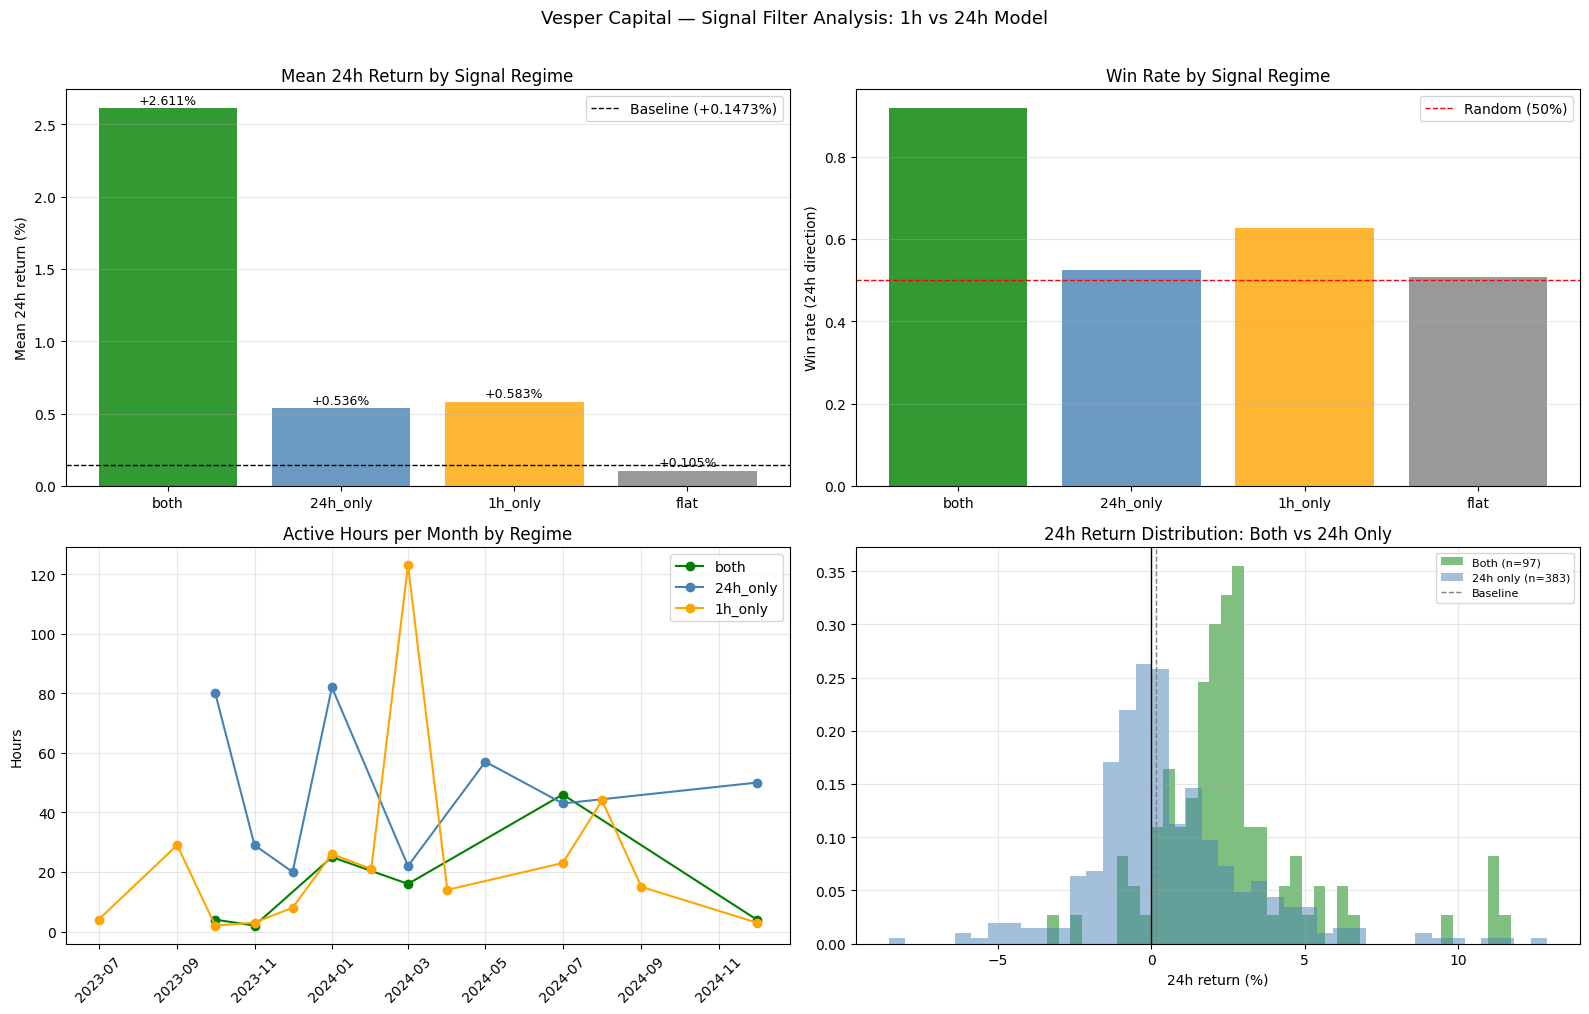

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Mean 24h return by regime
ax = axes[0, 0]
regimes = [r['regime'] for r in regime_stats]
means   = [r['mean_ret'] for r in regime_stats]
colors  = ['green' if r['regime']=='both' else
           'steelblue' if r['regime']=='24h_only' else
           'orange' if r['regime']=='1h_only' else 'gray'
           for r in regime_stats]
bars = ax.bar(regimes, means, color=colors, alpha=0.8)
ax.axhline(base_mean, color='black', linewidth=1, linestyle='--',
           label=f'Baseline ({base_mean:+.4f}%)')
ax.set_title('Mean 24h Return by Signal Regime')
ax.set_ylabel('Mean 24h return (%)')
ax.legend()
ax.grid(alpha=0.3, axis='y')
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:+.3f}%', ha='center', va='bottom', fontsize=9)

# 2. Win rate by regime
ax = axes[0, 1]
win_rates = [r['win_rate'] for r in regime_stats]
ax.bar(regimes, win_rates, color=colors, alpha=0.8)
ax.axhline(0.5, color='red', linewidth=1, linestyle='--', label='Random (50%)')
ax.set_title('Win Rate by Signal Regime')
ax.set_ylabel('Win rate (24h direction)')
ax.legend()
ax.grid(alpha=0.3, axis='y')

# 3. Hours in each regime over time
ax = axes[1, 0]
combined['month_ts'] = combined['timestamp'].dt.to_period('M').dt.to_timestamp()
for regime, color in [('both','green'),('24h_only','steelblue'),('1h_only','orange')]:
    monthly_n = combined[combined['regime']==regime].groupby('month_ts').size()
    if len(monthly_n) > 0:
        ax.plot(monthly_n.index, monthly_n.values,
                marker='o', label=regime, color=color, linewidth=1.5)
ax.set_title('Active Hours per Month by Regime')
ax.set_ylabel('Hours')
ax.legend()
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# 4. Distribution of 24h returns: both vs 24h_only
ax = axes[1, 1]
both_rets    = combined[combined['regime']=='both']['ret_24h']
only_24h_rets = combined[combined['regime']=='24h_only']['ret_24h']
if len(both_rets) > 0:
    ax.hist(both_rets.clip(-20,20), bins=40, alpha=0.5,
            color='green', label=f'Both (n={len(both_rets)})', density=True)
if len(only_24h_rets) > 0:
    ax.hist(only_24h_rets.clip(-20,20), bins=40, alpha=0.5,
            color='steelblue', label=f'24h only (n={len(only_24h_rets)})', density=True)
ax.axvline(0, color='black', linewidth=1)
ax.axvline(base_mean, color='gray', linewidth=1, linestyle='--', label='Baseline')
ax.set_title('24h Return Distribution: Both vs 24h Only')
ax.set_xlabel('24h return (%)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle('Vesper Capital — Signal Filter Analysis: 1h vs 24h Model',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 9. Verdict & recommendation

In [9]:
print("=" * 70)
print("VERDICT & RECOMMENDATION")
print("=" * 70)
print()

both_n    = combined[combined['regime']=='both'].shape[0]
only_24h_n = combined[combined['regime']=='24h_only'].shape[0]
total_24h_signals = both_n + only_24h_n

if both_n == 0:
    print("No hours where both models fired simultaneously.")
    print("Models are firing on completely different hours.")
    print("Recommendation: use 24h model alone.")
else:
    overlap_pct = both_n / total_24h_signals * 100
    print(f"24h model fires:        {total_24h_signals:,} hours")
    print(f"1h model also fires:    {both_n:,} hours ({overlap_pct:.1f}% of 24h signals)")
    print(f"1h model silent:        {only_24h_n:,} hours")
    print()

    if both_stats and only_24h_stats:
        filter_improvement = both_stats['edge'] - only_24h_stats['edge']
        signal_reduction   = (1 - both_n / total_24h_signals) * 100
        print(f"Edge improvement with filter:  {filter_improvement:+.4f}%/hr")
        print(f"Signal reduction with filter:  {signal_reduction:.1f}% fewer entries")
        print()

        if filter_improvement > 0.20:
            print("STRONG FILTER — implement 1h confirmation in capital simulation")
            print("  Only enter 24h positions when 1h model also agrees")
        elif filter_improvement > 0.05:
            print("MODERATE FILTER — worth testing in capital simulation")
            print("  The edge improvement is real but modest")
        else:
            print("WEAK FILTER — 1h model adds little as a confirmation signal")
            print("  Stick with 24h model alone; revisit after wallet pool redesign")

print()
print("Next step: if filter adds value, modify simulate_capital_allocation")
print("in combined_model.ipynb to only enter when pos_1h > 0 at entry hour.")


VERDICT & RECOMMENDATION

24h model fires:        480 hours
1h model also fires:    97 hours (20.2% of 24h signals)
1h model silent:        383 hours

Edge improvement with filter:  +2.0754%/hr
Signal reduction with filter:  79.8% fewer entries

STRONG FILTER — implement 1h confirmation in capital simulation
  Only enter 24h positions when 1h model also agrees

Next step: if filter adds value, modify simulate_capital_allocation
in combined_model.ipynb to only enter when pos_1h > 0 at entry hour.


In [10]:
# Quick check before implementing — is the improvement concentrated 
# in one or two months or spread across the period?
both_monthly = combined[combined['regime']=='both'].groupby('month').agg(
    n         = ('ret_24h', 'count'),
    mean_ret  = ('ret_24h', 'mean'),
    win_rate  = ('ret_24h', lambda x: (x>0).mean())
).reset_index()

only_24h_monthly = combined[combined['regime']=='24h_only'].groupby('month').agg(
    n         = ('ret_24h', 'count'),
    mean_ret  = ('ret_24h', 'mean'),
).reset_index().rename(columns={'mean_ret':'mean_ret_24h_only'})

comparison = both_monthly.merge(
    only_24h_monthly[['month','mean_ret_24h_only']], 
    on='month', how='left'
)
comparison['improvement'] = comparison['mean_ret'] - comparison['mean_ret_24h_only'].fillna(0)

print("Monthly breakdown — both regime vs 24h_only:")
print(comparison.to_string(index=False))
print()
print(f"Months where 'both' outperforms '24h_only': "
      f"{(comparison['improvement'] > 0).sum()} / {len(comparison)}")

Monthly breakdown — both regime vs 24h_only:
  month  n  mean_ret  win_rate  mean_ret_24h_only  improvement
2023-10  4  1.066849  1.000000           0.332017     0.734832
2023-11  2  6.518918  1.000000           1.890688     4.628229
2024-01 25  1.423093  0.880000          -0.057418     1.480511
2024-03 16  5.222088  0.875000           2.760786     2.461302
2024-07 46  2.455991  0.956522          -1.150515     3.606506
2024-12  4  0.970166  0.750000           1.182051    -0.211885

Months where 'both' outperforms '24h_only': 5 / 6
